In [ ]:
import torch
import matplotlib.pyplot as plt
import numpy as np

BASE = '/u/zup7mn/Classes/NN/digit4/state/diffusion/v3_score'

imgs_n4   = torch.load(f'{BASE}/generated_swap_N4.pt', map_location='cpu')
scores_n4 = torch.load(f'{BASE}/scores_swap_N4.pt',   map_location='cpu')
imgs_n8   = torch.load(f'{BASE}/generated_swap_N8.pt', map_location='cpu')
scores_n8 = torch.load(f'{BASE}/scores_swap_N8.pt',   map_location='cpu')

print('N4 images:', imgs_n4.shape, '  scores:', scores_n4.shape)
print('N8 images:', imgs_n8.shape, '  scores:', scores_n8.shape)

N4 images: torch.Size([10000, 1, 28, 28])   scores: torch.Size([10000])
N8 images: torch.Size([10000, 1, 28, 28])   scores: torch.Size([10000])


In [2]:
def show_grid(images, title, scores=None, nrow=10):
    n = len(images)
    ncols = nrow
    nrows = (n + ncols - 1) // ncols
    fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 1.4, nrows * 1.5))
    axes = np.array(axes).reshape(nrows, ncols)
    for i in range(nrows * ncols):
        ax = axes[i // ncols, i % ncols]
        if i < n:
            img = images[i].squeeze().numpy()
            ax.imshow(img, cmap='gray', vmin=0, vmax=1)
            if scores is not None:
                ax.set_title(f'{scores[i]:.4f}', fontsize=6)
        ax.axis('off')
    fig.suptitle(title, fontsize=13, fontweight='bold', y=1.01)
    plt.tight_layout()
    plt.show()

## N=4: 50 random samples

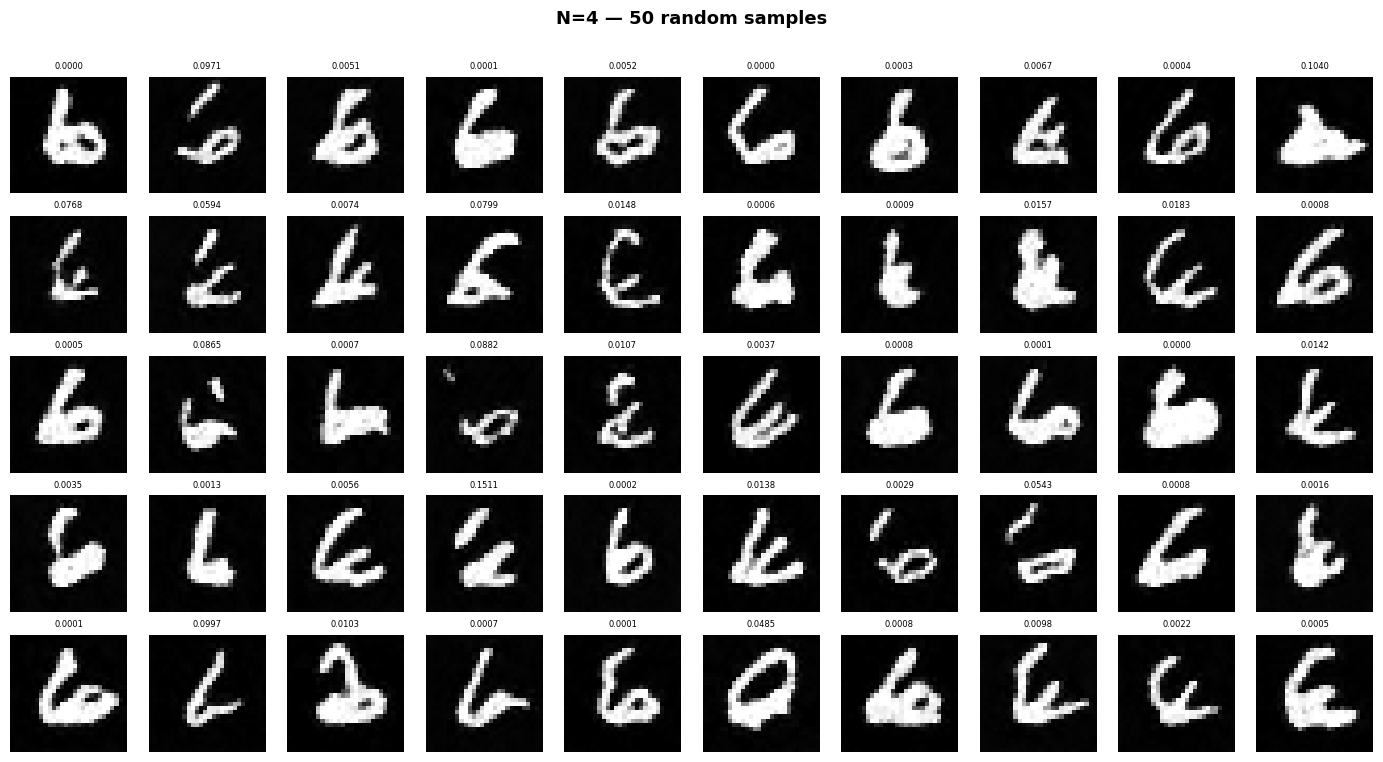

In [3]:
torch.manual_seed(0)
rand_idx_n4    = torch.randperm(len(imgs_n4))[:50]
rand_imgs_n4   = imgs_n4[rand_idx_n4].clamp(0, 1)
rand_scores_n4 = scores_n4[rand_idx_n4]
show_grid(rand_imgs_n4, 'N=4 — 50 random samples', scores=rand_scores_n4)

## N=4: top 50 by score

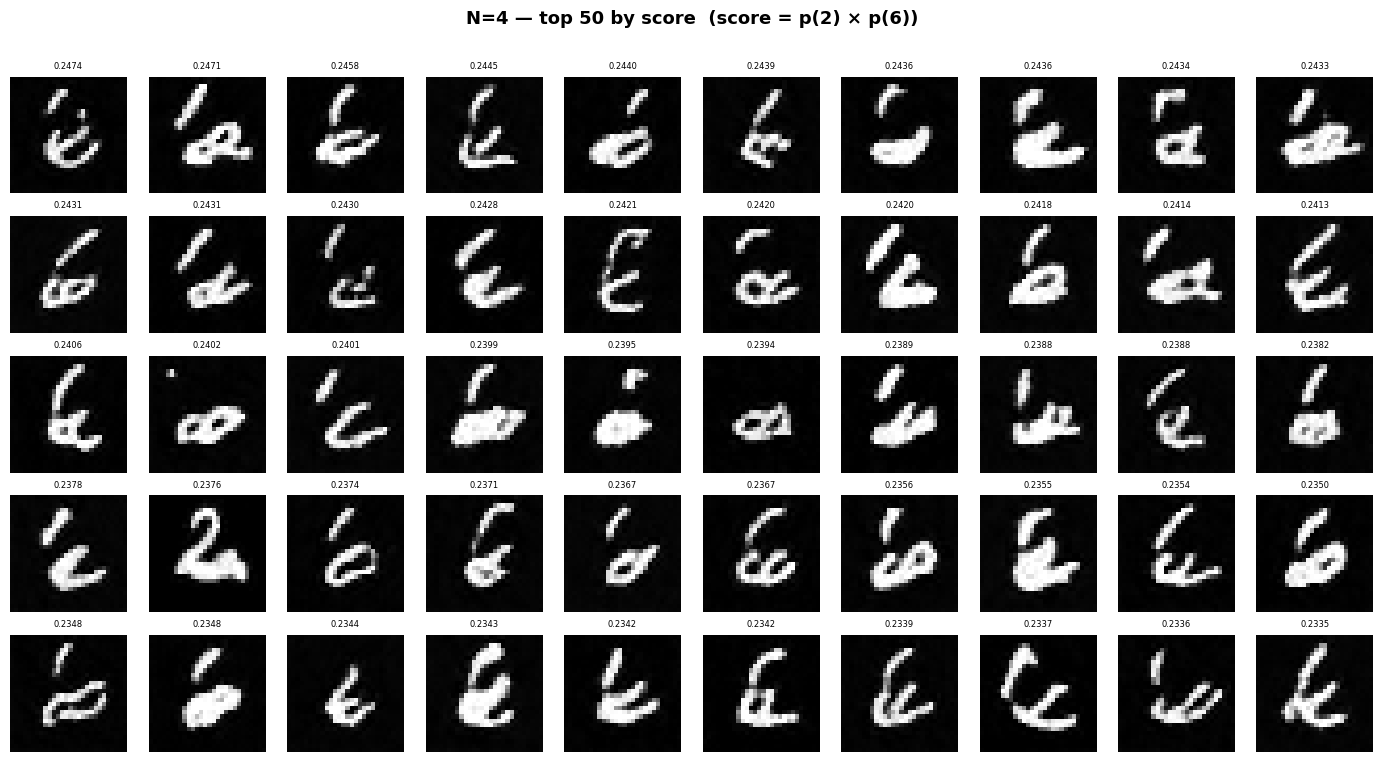

In [4]:
top_idx_n4    = scores_n4.argsort(descending=True)[:50]
top_imgs_n4   = imgs_n4[top_idx_n4].clamp(0, 1)
top_scores_n4 = scores_n4[top_idx_n4]
show_grid(top_imgs_n4, 'N=4 — top 50 by score  (score = p(2) × p(6))', scores=top_scores_n4)

## N=8: 50 random samples

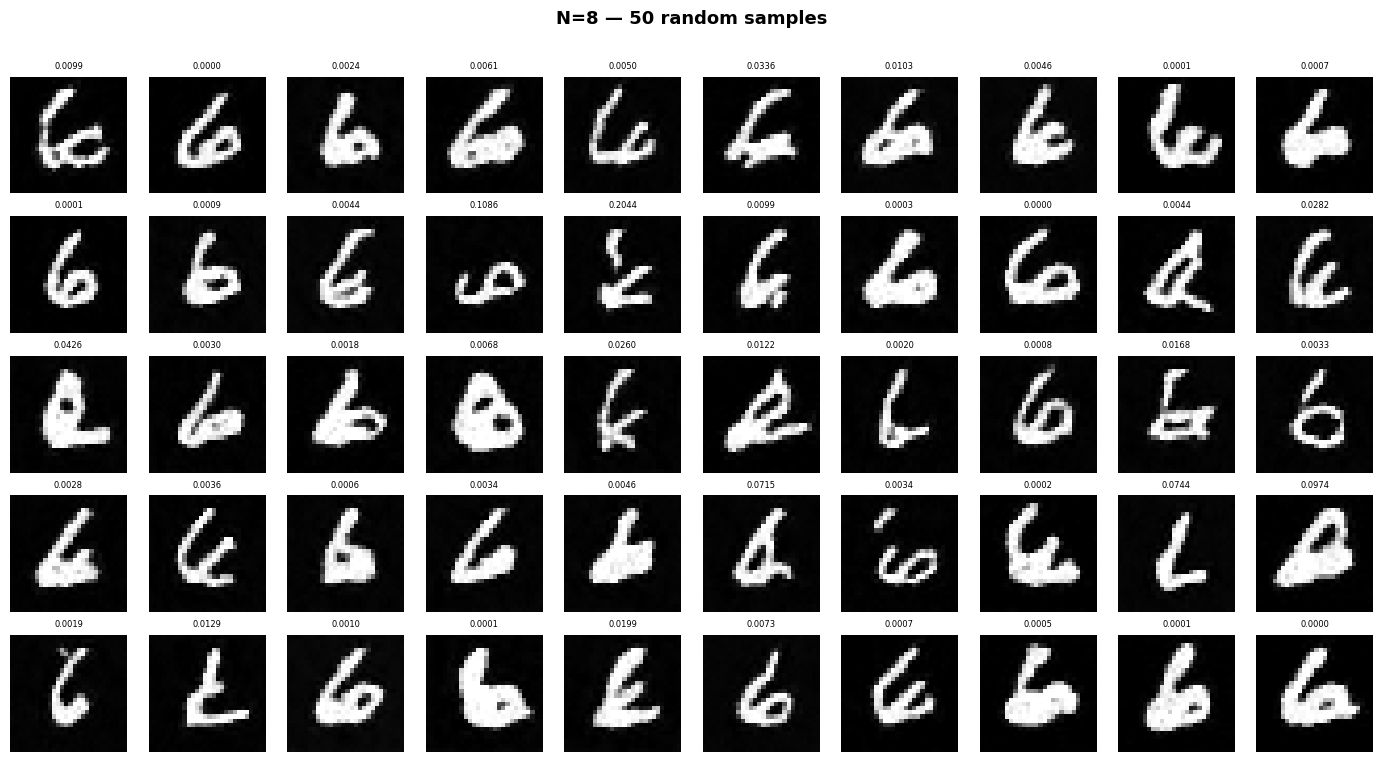

In [5]:
torch.manual_seed(0)
rand_idx_n8    = torch.randperm(len(imgs_n8))[:50]
rand_imgs_n8   = imgs_n8[rand_idx_n8].clamp(0, 1)
rand_scores_n8 = scores_n8[rand_idx_n8]
show_grid(rand_imgs_n8, 'N=8 — 50 random samples', scores=rand_scores_n8)

## N=8: top 50 by score

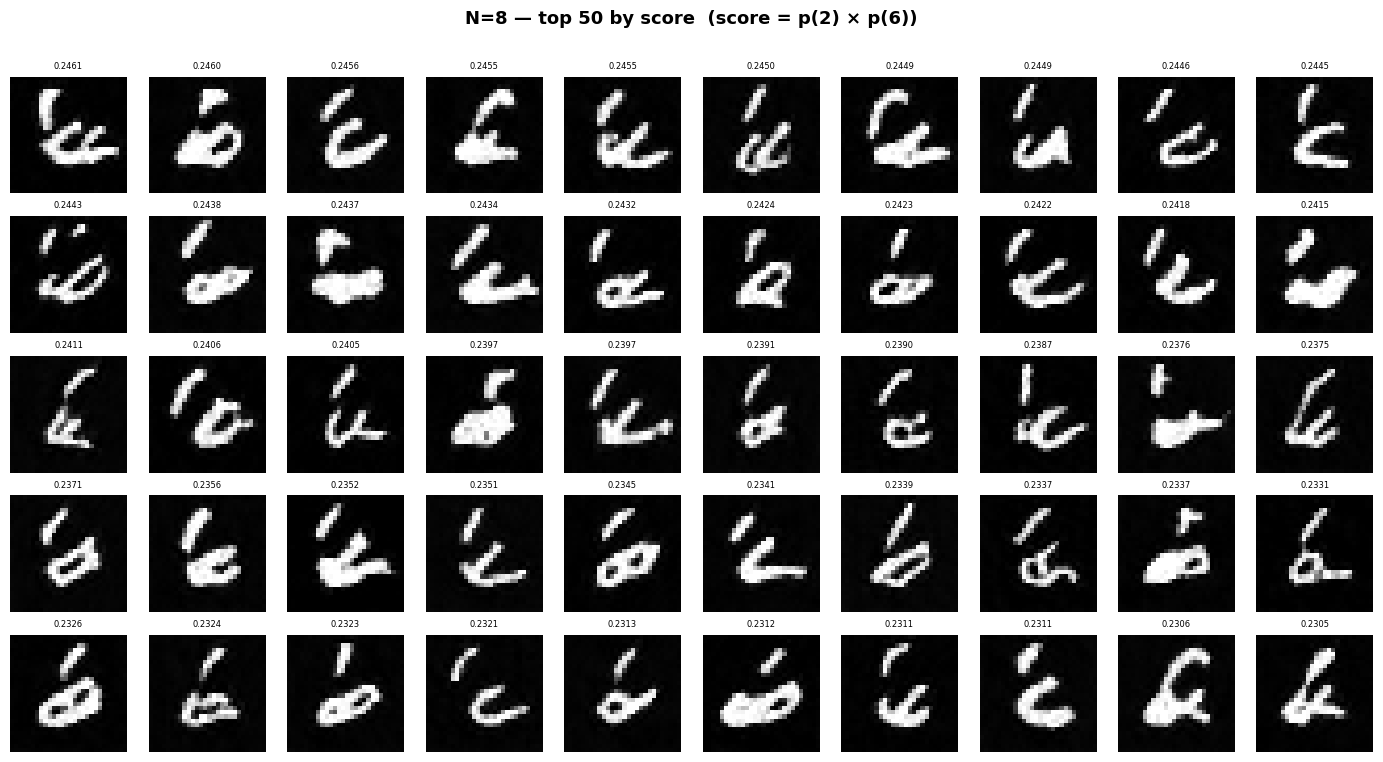

In [6]:
top_idx_n8    = scores_n8.argsort(descending=True)[:50]
top_imgs_n8   = imgs_n8[top_idx_n8].clamp(0, 1)
top_scores_n8 = scores_n8[top_idx_n8]
show_grid(top_imgs_n8, 'N=8 — top 50 by score  (score = p(2) × p(6))', scores=top_scores_n8)